In [3]:
import duckdb
import matplotlib.pyplot as plt
import numpy as np
conn = duckdb.connect()

def q(query: str):
    return conn.execute(query).df()

In [15]:
q('''
select * 
from '../traces/fb23/reag.parquet'
limit 5
  ''')

,timestamp,cacheKey,OpType,objectSize,responseSize,responseHeaderSize,rangeStart,rangeEnd,TTL,SamplingRate,cache_hit,item_value,RequestHandler,cdn_content_type_id,vip_type
0,1678863509425,0067813353300000000000000000000000000000000000...,1,-1,246307,547,-1,-1,1209600,0.0001,0,1,1000,9,2000
1,1678863511382,0067813353400000000000000000000000000000000000...,1,-1,2736128,0,-1,-1,1209600,0.0001,0,1,1000,2,2000
2,1678863569821,0067813353500000000000000000000000000000000000...,1,25568,26063,450,-1,-1,1209600,0.0001,0,1,1000,15,2000
3,1678863576365,0067813353600000000000000000000000000000000000...,1,20914,23493,2561,-1,-1,1209600,0.0001,0,0,1001,6,2001
4,1678863577913,0067813353700000000000000000000000000000000000...,1,10243,11691,1448,-1,-1,900,0.0001,0,1,1002,28,2002


In [13]:
q('''
select count(*) 
from '../traces/fb23/reag.parquet'
  ''')

,count_star()
0,50114842


In [29]:
q('''
select count(*) 
from '../traces/wm/t-all.parquet'
  ''')

,count_star()
0,197819321


In [50]:
q('''
select server, count(*) 
from '../traces/cf/**/*.parquet'
group by server
order by server asc
  ''')

,server,count_star()
0,106m105,611934154
1,106m106,737911445
2,243m12,585034405
3,243m13,633171931
4,411m264,350792601
5,411m325,390182372
6,472m378,305423630
7,472m379,322921382


In [25]:
q('''
with stats as (
    select cacheKey, count(*) as access_count
    from '../traces/fb23/reag.parquet'
    group by cacheKey
)
select
    sum(case when access_count = 1 then 1 else 0 end) / count(*) as a1,
    sum(case when access_count = 2 then 1 else 0 end) / count(*) as a2,
    sum(case when access_count = 3 then 1 else 0 end) / count(*) as a3,
    sum(case when access_count = 4 then 1 else 0 end) / count(*) as a4,
    sum(case when access_count = 5 then 1 else 0 end) / count(*) as a5
from stats
''')

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,a1,a2,a3,a4,a5
0,0.650057,0.208726,0.053713,0.026738,0.013599


In [27]:
q('''
with stats as (
    select key, count(*) as access_count
    from '../traces/wm/t-all.parquet'
    group by key
)
select
    sum(case when access_count = 1 then 1 else 0 end) / count(*) as a1,
    sum(case when access_count = 2 then 1 else 0 end) / count(*) as a2,
    sum(case when access_count = 3 then 1 else 0 end) / count(*) as a3,
    sum(case when access_count = 4 then 1 else 0 end) / count(*) as a4,
    sum(case when access_count = 5 then 1 else 0 end) / count(*) as a5
from stats
''')

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,a1,a2,a3,a4,a5
0,0.558991,0.138926,0.066806,0.040476,0.027484


In [4]:
reag_access_counts = q('''
select count(cacheKey) as cnt, count(cacheKey) / 50114842 as frac
from '../traces/fb23/reag.parquet'
group by cacheKey
order by cnt desc
limit 5000
  ''')
reag_access_counts

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,cnt,frac
0,11125252,0.221995
1,202798,0.004047
2,111075,0.002216
3,98938,0.001974
4,89733,0.001791
...,...,...
4995,282,0.000006
4996,282,0.000006
4997,282,0.000006
4998,282,0.000006


In [5]:
cf_access_counts = q('''
select count(key) as cnt, count(key) / 611934154 as frac
from "../traces/cf/**/*.parquet"
where server = '106m105'
group by key
order by cnt desc
limit 5000
  ''')
cf_access_counts

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,cnt,frac
0,9324811,0.015238
1,7554698,0.012346
2,7544839,0.012329
3,6244059,0.010204
4,4926479,0.008051
...,...,...
4995,8984,0.000015
4996,8981,0.000015
4997,8981,0.000015
4998,8978,0.000015


In [6]:
wm_access_counts = q('''
select count(key) as cnt, count(key) / 197819321 as frac
from '../traces/wm/t-all.parquet'
group by key
order by cnt desc
limit 5000
  ''')
wm_access_counts

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,cnt,frac
0,946048,0.004782
1,765288,0.003869
2,275306,0.001392
3,209517,0.001059
4,120681,0.000610
...,...,...
4995,2681,0.000014
4996,2680,0.000014
4997,2680,0.000014
4998,2680,0.000014


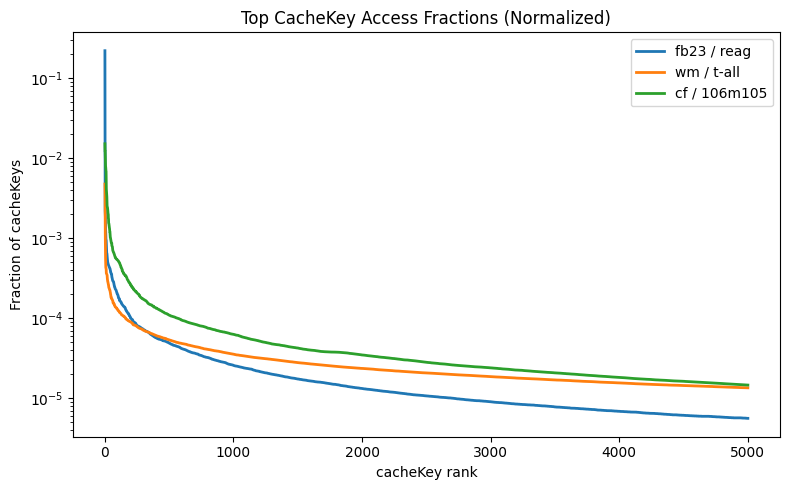

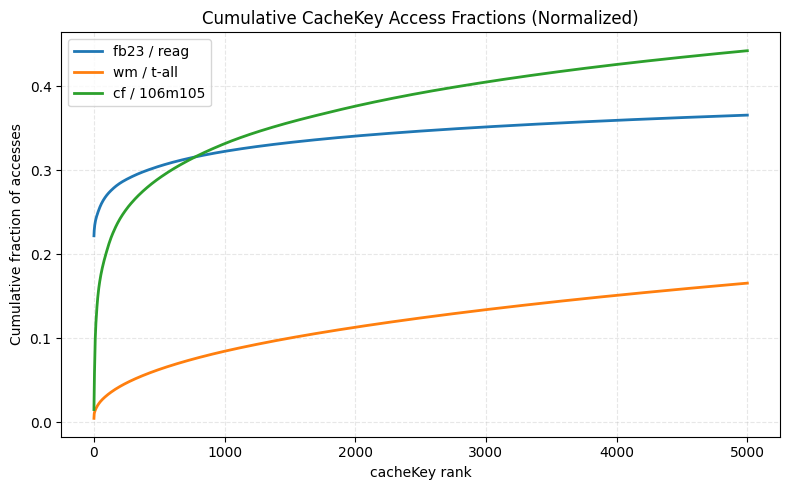

In [7]:
show = 5000

ranks_reag = np.arange(1, len(reag_access_counts) + 1)[:show]
ranks_wm = np.arange(1, len(wm_access_counts) + 1)[:show]
ranks_cf = np.arange(1, len(cf_access_counts) + 1)[:show]
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ranks_reag, reag_access_counts['frac'][:show], label='fb23 / reag', linewidth=2)
ax.plot(ranks_wm, wm_access_counts['frac'][:show], label='wm / t-all', linewidth=2)
ax.plot(ranks_cf, cf_access_counts['frac'][:show], label='cf / 106m105', linewidth=2)
ax.set_xlabel('cacheKey rank')
ax.set_ylabel('Fraction of cacheKeys')
ax.set_title('Top CacheKey Access Fractions (Normalized)')
ax.set_yscale('log')
ax.legend()
plt.tight_layout()

cum_reag = np.cumsum(reag_access_counts['frac'].to_numpy())
cum_wm = np.cumsum(wm_access_counts['frac'].to_numpy())
cum_cf = np.cumsum(cf_access_counts['frac'].to_numpy())
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ranks_reag, cum_reag[:show], label='fb23 / reag', linewidth=2)
ax.plot(ranks_wm, cum_wm[:show], label='wm / t-all', linewidth=2)
ax.plot(ranks_cf, cum_cf[:show], label='cf / 106m105', linewidth=2)
ax.set_xlabel('cacheKey rank')
ax.set_ylabel('Cumulative fraction of accesses')
ax.set_title('Cumulative CacheKey Access Fractions (Normalized)')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

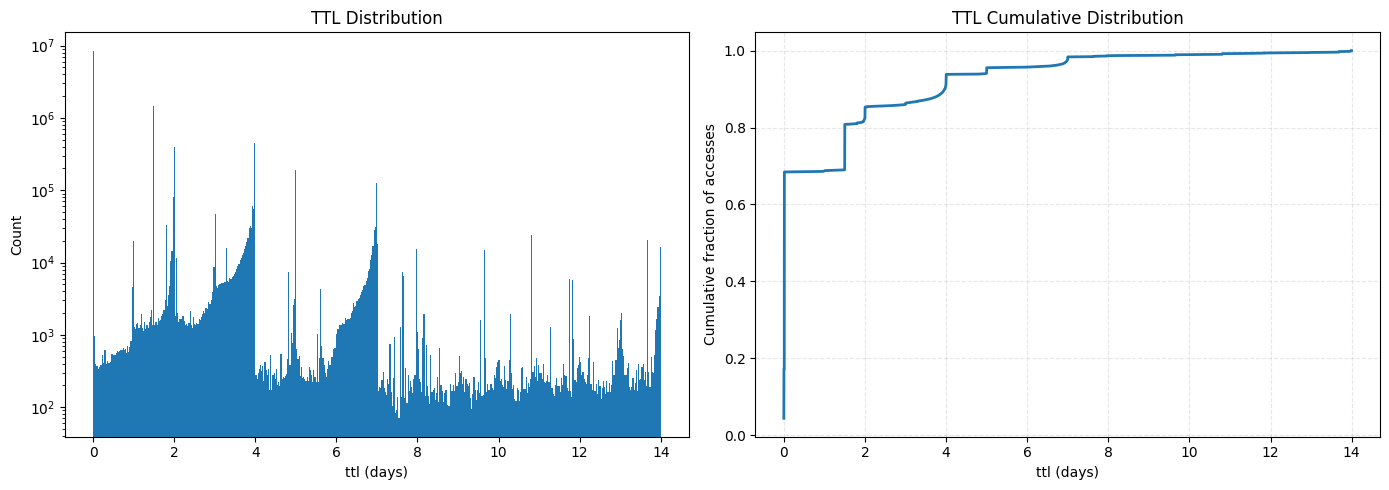

In [10]:
df = q('''
select ttl / 24 / 3600 as ttl, count(*) as cnt
from '../traces/fb23/reag.parquet'
group by ttl
having ttl < 14*86400
order by ttl asc
  ''')
df_sorted = df.sort_values('ttl')
cum_counts = np.cumsum(df_sorted['cnt'].to_numpy())
cum_fraction = cum_counts / cum_counts[-1]

fig, (ax_hist, ax_cdf) = plt.subplots(1, 2, figsize=(14, 5))
ax_hist.hist(
    df['ttl'],
    weights=df['cnt'],
    bins=500,
    log=True,
 )
ax_hist.set_xlabel('ttl (days)')
ax_hist.set_ylabel('Count')
ax_hist.set_title('TTL Distribution')

ax_cdf.plot(df_sorted['ttl'], cum_fraction, linewidth=2)
ax_cdf.set_xlabel('ttl (days)')
ax_cdf.set_ylabel('Cumulative fraction of accesses')
ax_cdf.set_title('TTL Cumulative Distribution')
ax_cdf.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

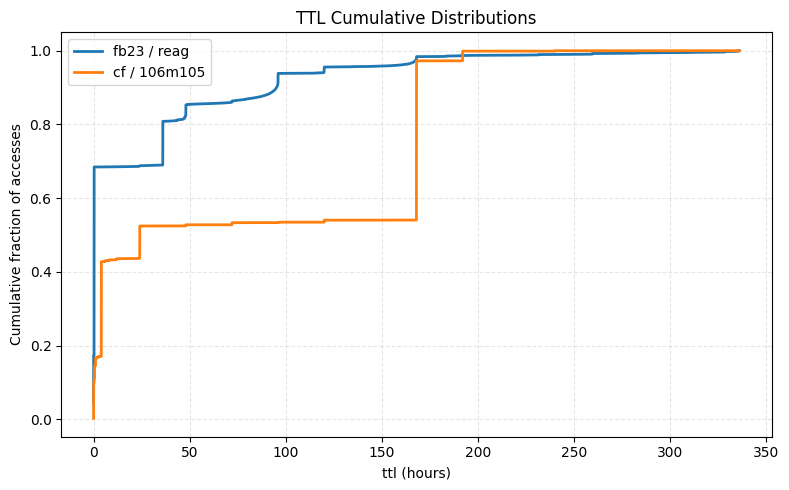

In [13]:
df_fb23_ttl = q('''
select ttl / 3600 as ttl_hours, count(*) as cnt
from '../traces/fb23/reag.parquet'
where ttl < 14*24*3600
group by ttl_hours
order by ttl_hours asc
  ''')
df_cf_ttl = q('''
select expiry_time / 3600 as ttl_hours, count(*) as cnt
from '../traces/cf/parquet/**/*.parquet'
where expiry_time < 14*24*3600 and server = '106m105'
group by ttl_hours
order by ttl_hours asc
  ''')

def cumulative_curve(df):
    # Convert aggregated TTL counts into a monotonic CDF curve.
    df_sorted = df.sort_values('ttl_hours')
    cum_counts = np.cumsum(df_sorted['cnt'].to_numpy())
    return df_sorted['ttl_hours'].to_numpy(), cum_counts / cum_counts[-1]

ttl_fb23, cdf_fb23 = cumulative_curve(df_fb23_ttl)
ttl_cf, cdf_cf = cumulative_curve(df_cf_ttl)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ttl_fb23, cdf_fb23, label='fb23 / reag', linewidth=2)
ax.plot(ttl_cf, cdf_cf, label='cf / 106m105', linewidth=2)
ax.set_xlabel('ttl (hours)')
ax.set_ylabel('Cumulative fraction of accesses')
ax.set_title('TTL Cumulative Distributions')
ax.grid(True, linestyle='--', alpha=0.3)
ax.legend()
plt.tight_layout()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

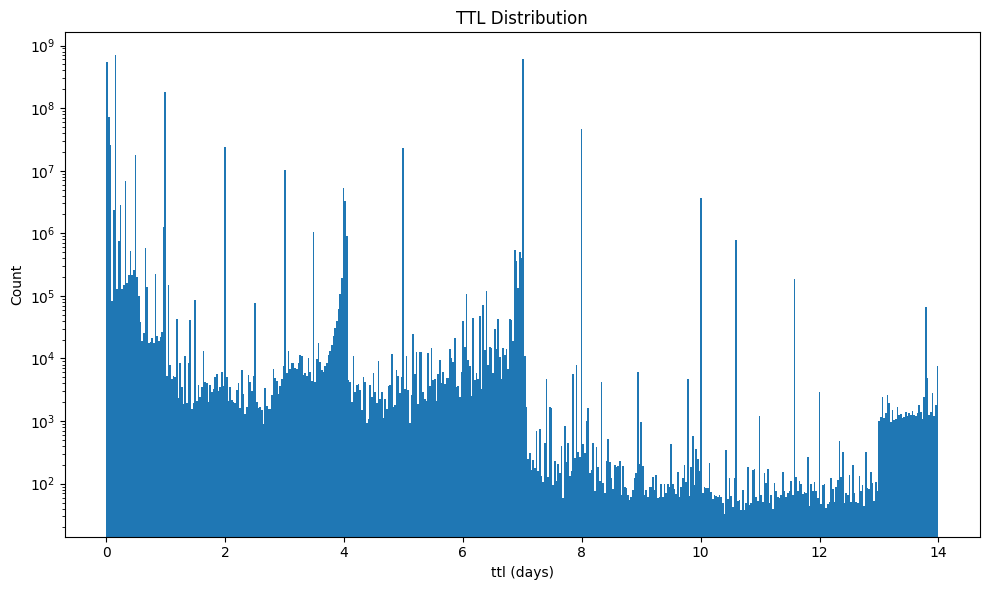

In [43]:
df = q('''
select expiry_time / 24 / 3600 as ttl, count(*) as cnt
from '../traces/cf/parquet/**/*.parquet'
group by ttl
having ttl < 14
order by ttl asc
  ''')

plt.figure(figsize=(10, 6))
plt.hist(
    df['ttl'],
    weights=df['cnt'],
    bins=500,
    log=True,
 )
plt.xlabel('ttl (days)')
plt.ylabel('Count')
plt.title('TTL Distribution')
plt.tight_layout()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

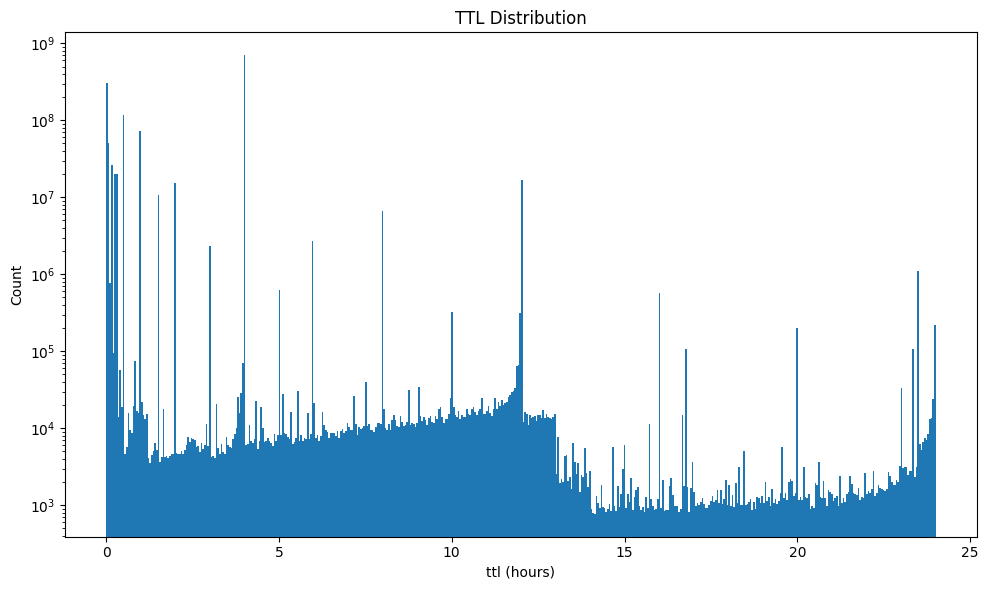

In [46]:
df = q('''
select expiry_time / 3600 as ttl, count(*) as cnt
from '../traces/cf/parquet/**/*.parquet'
group by ttl
having ttl < 24
order by ttl asc
  ''')

plt.figure(figsize=(10, 6))
plt.hist(
    df['ttl'],
    weights=df['cnt'],
    bins=500,
    log=True,
 )
plt.xlabel('ttl (hours)')
plt.ylabel('Count')
plt.title('TTL Distribution')
plt.tight_layout()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

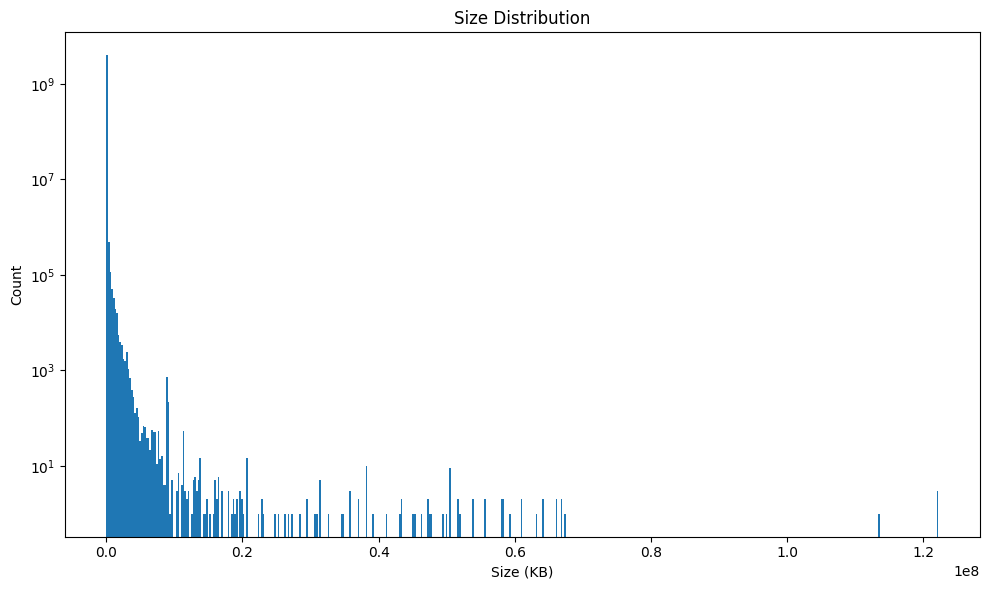

In [48]:
df = q('''
select size / 1024 as sizekb, count(*) as cnt
from '../traces/cf/parquet/**/*.parquet'
group by sizekb
order by sizekb asc
  ''')

plt.figure(figsize=(10, 6))
plt.hist(
    df['sizekb'],
    weights=df['cnt'],
    bins=500,
    log=True,
 )
plt.xlabel('Size (KB)')
plt.ylabel('Count')
plt.title('Size Distribution')
plt.tight_layout()

In [47]:
q('''
select *
from '../traces/cf/parquet/**/*.parquet'
limit 10
  ''')

,timestamp,key,zone,size,expiry_time,stale_time,method,mime,filename,server
0,1745712000,28e3c4805dc376c3,a9deca06e76f5a50,161189,300,0,0,text/html; charset=utf-8,../traces/106m105.csv.zst,106m105
1,1745712000,5bb1c025b485e25e,e579e303a6479bc2,242,14400,0,0,application/json,../traces/106m105.csv.zst,106m105
2,1745712000,5bb1c025b485e25e,e579e303a6479bc2,242,14400,0,0,application/json,../traces/106m105.csv.zst,106m105
3,1745712000,5bb1c025b485e25e,e579e303a6479bc2,242,14400,0,0,application/json,../traces/106m105.csv.zst,106m105
4,1745712000,7bc224a22b6e3b80,e579e303a6479bc2,242,14400,0,0,application/json,../traces/106m105.csv.zst,106m105
5,1745712000,7bc224a22b6e3b80,e579e303a6479bc2,242,14400,0,0,application/json,../traces/106m105.csv.zst,106m105
6,1745712000,7bc224a22b6e3b80,e579e303a6479bc2,242,14400,0,0,application/json,../traces/106m105.csv.zst,106m105
7,1745712000,7bc224a22b6e3b80,e579e303a6479bc2,242,14400,0,0,application/json,../traces/106m105.csv.zst,106m105
8,1745712000,7bc224a22b6e3b80,e579e303a6479bc2,242,14400,0,0,application/json,../traces/106m105.csv.zst,106m105
9,1745712000,7bc224a22b6e3b80,e579e303a6479bc2,242,14400,0,0,application/json,../traces/106m105.csv.zst,106m105
